In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from pathlib import Path
from pydub import AudioSegment

print("Import thư viện thành công!")

Import thư viện thành công!


In [2]:
# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN
# ==========================================

PROJECT_DIR = Path.cwd()

AUDIO_DIR = PROJECT_DIR / "Audio"
DATASET_DIR = PROJECT_DIR / "dataset"
FIGURES_DIR = PROJECT_DIR / "figures"

# Tạo các thư mục cần thiết
DATASET_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Thư mục project:")
print(PROJECT_DIR)

print("\nThư mục Audio:")
print(AUDIO_DIR)

print("\nThư mục Dataset:")
print(DATASET_DIR)

print("\nThư mục Figures:")
print(FIGURES_DIR)

Thư mục project:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh

Thư mục Audio:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\Audio

Thư mục Dataset:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset

Thư mục Figures:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures


In [7]:
# ==========================================
# TÌM TOÀN BỘ FILE M4A TRONG THƯ MỤC AUDIO
# ==========================================

from pathlib import Path
import re

# Tìm thư mục Audio
AUDIO_DIR = Path.cwd() / "Audio"

print("Thư mục hiện tại:")
print(Path.cwd())

print("\nThư mục Audio:")
print(AUDIO_DIR)

print("\nAudio tồn tại:", AUDIO_DIR.exists())

# Lấy tất cả file .m4a
m4a_files = list(AUDIO_DIR.glob("*.m4a"))

# Sắp xếp theo số trong tên file
def get_file_number(file):
    match = re.search(r"(\d+)", file.stem)
    return int(match.group(1)) if match else 9999

m4a_files = sorted(m4a_files, key=get_file_number)

print("\nSố file M4A tìm thấy:", len(m4a_files))
print("-" * 60)

for i, file in enumerate(m4a_files, start=1):
    print(f"{i:02d}. {file.name}")

Thư mục hiện tại:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh

Thư mục Audio:
c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\Audio

Audio tồn tại: True

Số file M4A tìm thấy: 25
------------------------------------------------------------
01. Bản ghi mới 1.m4a
02. Bản ghi mới 2.m4a
03. Bản ghi mới 3.m4a
04. Bản ghi mới 4.m4a
05. Bản ghi mới 5.m4a
06. Bản ghi mới 6.m4a
07. Bản ghi mới 7.m4a
08. Bản ghi mới 8.m4a
09. Bản ghi mới 9.m4a
10. Bản ghi mới 10.m4a
11. Bản ghi mới 11.m4a
12. Bản ghi mới 12.m4a
13. Bản ghi mới 13.m4a
14. Bản ghi mới 14.m4a
15. Bản ghi mới 15.m4a
16. Bản ghi mới 16.m4a
17. Bản ghi mới 17.m4a
18. Bản ghi mới 18.m4a
19. Bản ghi mới 19.m4a
20. Bản ghi mới 20.m4a
21. Bản ghi mới 21.m4a
22. Bản ghi mới 22.m4a
23. Bản ghi mới 23.m4a
24. Bản ghi mới 24.m4a
25. Bản ghi mới 25.m4a


In [8]:
# ==========================================
# KIỂM TRA 25 FILE THEO THỨ TỰ
# ==========================================

if len(m4a_files) != 25:
    print(f"⚠️ Phát hiện {len(m4a_files)} file, không phải 25 file.")
else:
    print("✓ Đã tìm thấy đủ 25 file âm thanh.\n")

    for i, file in enumerate(m4a_files, start=1):
        print(f"{i:02d} → {file.name}")

✓ Đã tìm thấy đủ 25 file âm thanh.

01 → Bản ghi mới 1.m4a
02 → Bản ghi mới 2.m4a
03 → Bản ghi mới 3.m4a
04 → Bản ghi mới 4.m4a
05 → Bản ghi mới 5.m4a
06 → Bản ghi mới 6.m4a
07 → Bản ghi mới 7.m4a
08 → Bản ghi mới 8.m4a
09 → Bản ghi mới 9.m4a
10 → Bản ghi mới 10.m4a
11 → Bản ghi mới 11.m4a
12 → Bản ghi mới 12.m4a
13 → Bản ghi mới 13.m4a
14 → Bản ghi mới 14.m4a
15 → Bản ghi mới 15.m4a
16 → Bản ghi mới 16.m4a
17 → Bản ghi mới 17.m4a
18 → Bản ghi mới 18.m4a
19 → Bản ghi mới 19.m4a
20 → Bản ghi mới 20.m4a
21 → Bản ghi mới 21.m4a
22 → Bản ghi mới 22.m4a
23 → Bản ghi mới 23.m4a
24 → Bản ghi mới 24.m4a
25 → Bản ghi mới 25.m4a


In [9]:
# ==========================================
# KIỂM TRA PHÂN LOẠI 25 FILE
# ==========================================

word_groups = {
    "khong": ("không", 1, 5),
    "mot": ("một", 6, 10),
    "minh": ("minh", 11, 15),
    "do": ("đỏ", 16, 20),
    "trang": ("trắng", 21, 25)
}

for folder, (label, start, end) in word_groups.items():

    print(f"\n{label.upper()}")
    print("-" * 40)

    for i in range(start, end + 1):
        file = m4a_files[i - 1]
        print(f"{i:02d}. {file.name}")


KHÔNG
----------------------------------------
01. Bản ghi mới 1.m4a
02. Bản ghi mới 2.m4a
03. Bản ghi mới 3.m4a
04. Bản ghi mới 4.m4a
05. Bản ghi mới 5.m4a

MỘT
----------------------------------------
06. Bản ghi mới 6.m4a
07. Bản ghi mới 7.m4a
08. Bản ghi mới 8.m4a
09. Bản ghi mới 9.m4a
10. Bản ghi mới 10.m4a

MINH
----------------------------------------
11. Bản ghi mới 11.m4a
12. Bản ghi mới 12.m4a
13. Bản ghi mới 13.m4a
14. Bản ghi mới 14.m4a
15. Bản ghi mới 15.m4a

ĐỎ
----------------------------------------
16. Bản ghi mới 16.m4a
17. Bản ghi mới 17.m4a
18. Bản ghi mới 18.m4a
19. Bản ghi mới 19.m4a
20. Bản ghi mới 20.m4a

TRẮNG
----------------------------------------
21. Bản ghi mới 21.m4a
22. Bản ghi mới 22.m4a
23. Bản ghi mới 23.m4a
24. Bản ghi mới 24.m4a
25. Bản ghi mới 25.m4a


In [10]:
# ==========================================
# TẠO CẤU TRÚC DATASET
# ==========================================

DATASET_DIR = Path.cwd() / "dataset"

word_groups = {
    "khong": ("không", 1, 5),
    "mot": ("một", 6, 10),
    "minh": ("minh", 11, 15),
    "do": ("đỏ", 16, 20),
    "trang": ("trắng", 21, 25)
}

for folder in word_groups.keys():
    folder_path = DATASET_DIR / folder
    folder_path.mkdir(parents=True, exist_ok=True)

print("✓ Đã tạo cấu trúc dataset:\n")

for folder, (label, start, end) in word_groups.items():
    print(f"dataset/{folder}/  →  {label}")

✓ Đã tạo cấu trúc dataset:

dataset/khong/  →  không
dataset/mot/  →  một
dataset/minh/  →  minh
dataset/do/  →  đỏ
dataset/trang/  →  trắng


In [11]:
# ==========================================
# CHUYỂN M4A → WAV
# MONO + 16 kHz
# ==========================================

from pydub import AudioSegment

TARGET_SR = 16000

for folder, (label, start, end) in word_groups.items():

    output_dir = DATASET_DIR / folder

    print(f"\n{'=' * 50}")
    print(f"ĐANG XỬ LÝ: {label.upper()}")
    print(f"{'=' * 50}")

    for i in range(start, end + 1):

        # Lấy file trực tiếp từ danh sách m4a_files
        input_file = m4a_files[i - 1]

        # Số thứ tự trong từng lớp
        local_number = i - start + 1

        # Tên file WAV
        output_file = (
            output_dir /
            f"{folder}_{local_number:02d}.wav"
        )

        print(f"{input_file.name}")
        print(f"    ↓ {output_file}")

        # Đọc file M4A
        audio = AudioSegment.from_file(
            input_file,
            format="m4a"
        )

        # Chuyển thành mono
        audio = audio.set_channels(1)

        # Sampling rate = 16 kHz
        audio = audio.set_frame_rate(TARGET_SR)

        # Xuất WAV
        audio.export(
            output_file,
            format="wav"
        )

print("\n✓ HOÀN TẤT CHUYỂN ĐỔI 25 FILE!")


ĐANG XỬ LÝ: KHÔNG
Bản ghi mới 1.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\khong\khong_01.wav
Bản ghi mới 2.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\khong\khong_02.wav
Bản ghi mới 3.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\khong\khong_03.wav
Bản ghi mới 4.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\khong\khong_04.wav
Bản ghi mới 5.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\khong\khong_05.wav

ĐANG XỬ LÝ: MỘT
Bản ghi mới 6.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\mot\mot_01.wav
Bản ghi mới 7.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\mot\mot_02.wav
Bản ghi mới 8.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\mot\mot_03.wav
Bản ghi mới 9.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\mot\mot_04.wav
Bản ghi mới 10.m4a
    ↓ c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\dataset\mot\mot_05.wav

ĐANG XỬ LÝ: MINH
Bản ghi mới 

In [12]:
# ==========================================
# KIỂM TRA WAV
# ==========================================

all_wav_files = sorted(
    DATASET_DIR.rglob("*.wav")
)

print("Tổng số file WAV:", len(all_wav_files))
print()

for file in all_wav_files:

    y, sr = librosa.load(
        file,
        sr=None,
        mono=False
    )

    if y.ndim == 1:
        channels = 1
        samples = len(y)
    else:
        channels = y.shape[0]
        samples = y.shape[1]

    duration = samples / sr

    print(
        f"{file.parent.name:>6} | "
        f"{file.name:<15} | "
        f"SR={sr:<5} | "
        f"Channels={channels} | "
        f"Duration={duration:.2f}s"
    )

Tổng số file WAV: 25

    do | do_01.wav       | SR=16000 | Channels=1 | Duration=2.56s
    do | do_02.wav       | SR=16000 | Channels=1 | Duration=2.65s
    do | do_03.wav       | SR=16000 | Channels=1 | Duration=1.88s
    do | do_04.wav       | SR=16000 | Channels=1 | Duration=2.30s
    do | do_05.wav       | SR=16000 | Channels=1 | Duration=2.39s
 khong | khong_01.wav    | SR=16000 | Channels=1 | Duration=3.75s
 khong | khong_02.wav    | SR=16000 | Channels=1 | Duration=2.99s
 khong | khong_03.wav    | SR=16000 | Channels=1 | Duration=3.84s
 khong | khong_04.wav    | SR=16000 | Channels=1 | Duration=2.90s
 khong | khong_05.wav    | SR=16000 | Channels=1 | Duration=3.07s
  minh | minh_01.wav     | SR=16000 | Channels=1 | Duration=2.73s
  minh | minh_02.wav     | SR=16000 | Channels=1 | Duration=2.65s
  minh | minh_03.wav     | SR=16000 | Channels=1 | Duration=2.65s
  minh | minh_04.wav     | SR=16000 | Channels=1 | Duration=2.05s
  minh | minh_05.wav     | SR=16000 | Channels=1 | Dur

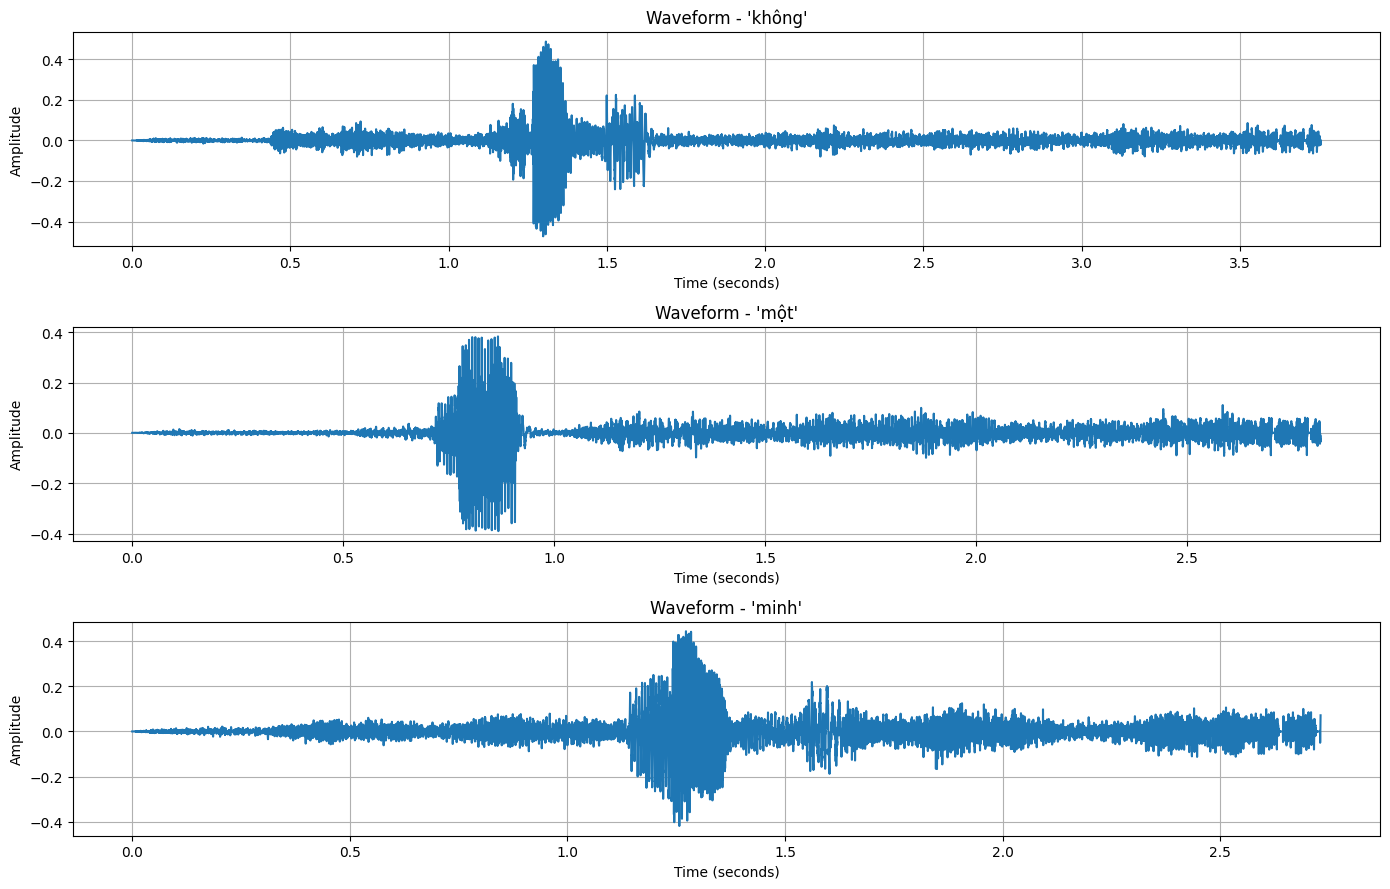

In [13]:
# ==========================================
# VẼ WAVEFORM
# ==========================================

selected_files = [
    ("không", DATASET_DIR / "khong" / "khong_01.wav"),
    ("một", DATASET_DIR / "mot" / "mot_01.wav"),
    ("minh", DATASET_DIR / "minh" / "minh_01.wav")
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 9)
)

for ax, (label, file) in zip(axes, selected_files):

    y, sr = librosa.load(
        file,
        sr=None,
        mono=True
    )

    time = np.arange(len(y)) / sr

    ax.plot(time, y)

    ax.set_title(f"Waveform - '{label}'")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")

    ax.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# LAB 2 - CẤU HÌNH PHÂN TÍCH
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from pathlib import Path
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ------------------------------------------
# Đường dẫn
# ------------------------------------------

PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "dataset"
TRIMMED_DIR = PROJECT_DIR / "trimmed_dataset"
FIGURES_DIR = PROJECT_DIR / "figures"

TRIMMED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ------------------------------------------
# Sampling
# ------------------------------------------

SR = 16000

# ------------------------------------------
# Framing
# ------------------------------------------

FRAME_MS = 25
HOP_MS = 10

FRAME_LENGTH = int(SR * FRAME_MS / 1000)
HOP_LENGTH = int(SR * HOP_MS / 1000)

# ------------------------------------------
# MFCC
# ------------------------------------------

PRE_EMPHASIS = 0.97
N_MELS = 24
N_MFCC = 13

print("Sampling rate:", SR)
print("Frame length:", FRAME_LENGTH, "samples")
print("Hop length:", HOP_LENGTH, "samples")
print("MFCC:", N_MFCC)
print("Mel filters:", N_MELS)
print("Pre-emphasis:", PRE_EMPHASIS)

Sampling rate: 16000
Frame length: 400 samples
Hop length: 160 samples
MFCC: 13
Mel filters: 24
Pre-emphasis: 0.97


In [15]:
# ==========================================
# FRAMING
# ==========================================

def framing(signal, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH):
    """
    Chia tín hiệu thành các frame.

    Parameters
    ----------
    signal : np.ndarray
        Tín hiệu âm thanh 1 chiều.
    frame_length : int
        Số mẫu trong một frame.
    hop_length : int
        Khoảng dịch giữa hai frame.

    Returns
    -------
    frames : np.ndarray
        Ma trận [số_frame, frame_length]
    """

    signal = np.asarray(signal, dtype=np.float32)

    if len(signal) < frame_length:
        signal = np.pad(
            signal,
            (0, frame_length - len(signal))
        )

    n_frames = 1 + int(
        np.ceil(
            (len(signal) - frame_length) / hop_length
        )
    )

    padded_length = (
        (n_frames - 1) * hop_length
        + frame_length
    )

    if len(signal) < padded_length:
        signal = np.pad(
            signal,
            (0, padded_length - len(signal))
        )

    frames = np.zeros(
        (n_frames, frame_length),
        dtype=np.float32
    )

    for i in range(n_frames):
        start = i * hop_length
        end = start + frame_length
        frames[i] = signal[start:end]

    return frames


print("✓ Hàm framing đã sẵn sàng")

✓ Hàm framing đã sẵn sàng


In [16]:
# ==========================================
# SHORT-TIME ENERGY / RMS + ZCR
# ==========================================

def calculate_rms(frames):
    """
    RMS cho từng frame.
    """
    
    return np.sqrt(
        np.mean(frames ** 2, axis=1) + 1e-10
    )


def calculate_energy(frames):
    """
    Short-Time Energy cho từng frame.
    """
    
    return np.sum(
        frames ** 2,
        axis=1
    )


def calculate_zcr(frames):
    """
    Zero-Crossing Rate cho từng frame.
    """

    signs = np.sign(frames)

    crossings = np.sum(
        np.abs(
            np.diff(signs, axis=1)
        ) > 0,
        axis=1
    )

    return crossings / frames.shape[1]


def analyze_energy_zcr(file_path):

    y, sr = librosa.load(
        file_path,
        sr=SR,
        mono=True
    )

    frames = framing(y)

    rms = calculate_rms(frames)
    energy = calculate_energy(frames)
    zcr = calculate_zcr(frames)

    frame_time = (
        np.arange(len(frames))
        * HOP_LENGTH
        / SR
    )

    return {
        "signal": y,
        "sr": sr,
        "frames": frames,
        "rms": rms,
        "energy": energy,
        "zcr": zcr,
        "time": frame_time
    }


print("✓ Hàm Energy + ZCR đã sẵn sàng")

✓ Hàm Energy + ZCR đã sẵn sàng


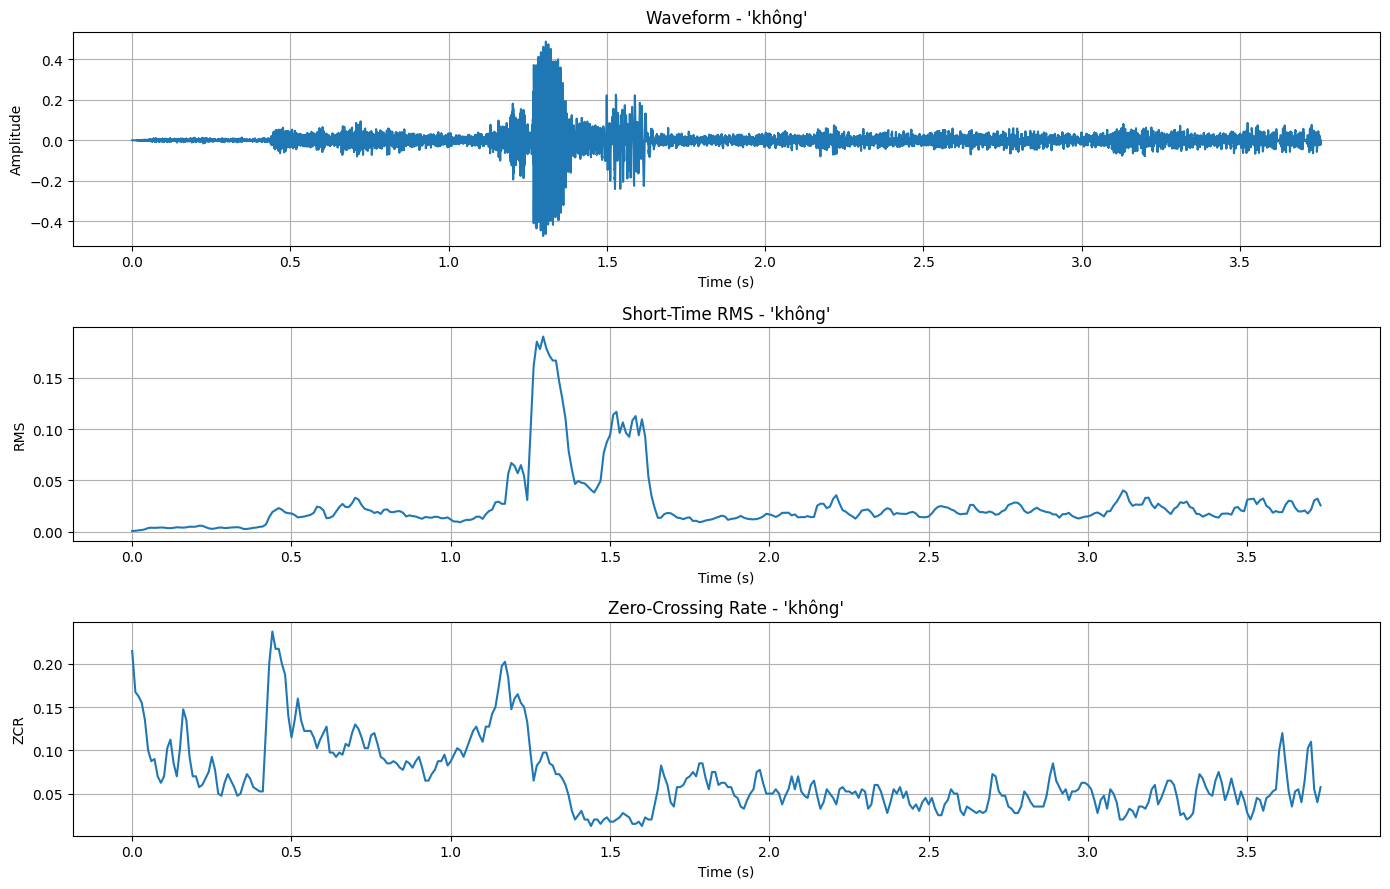

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\energy_zcr_không.png


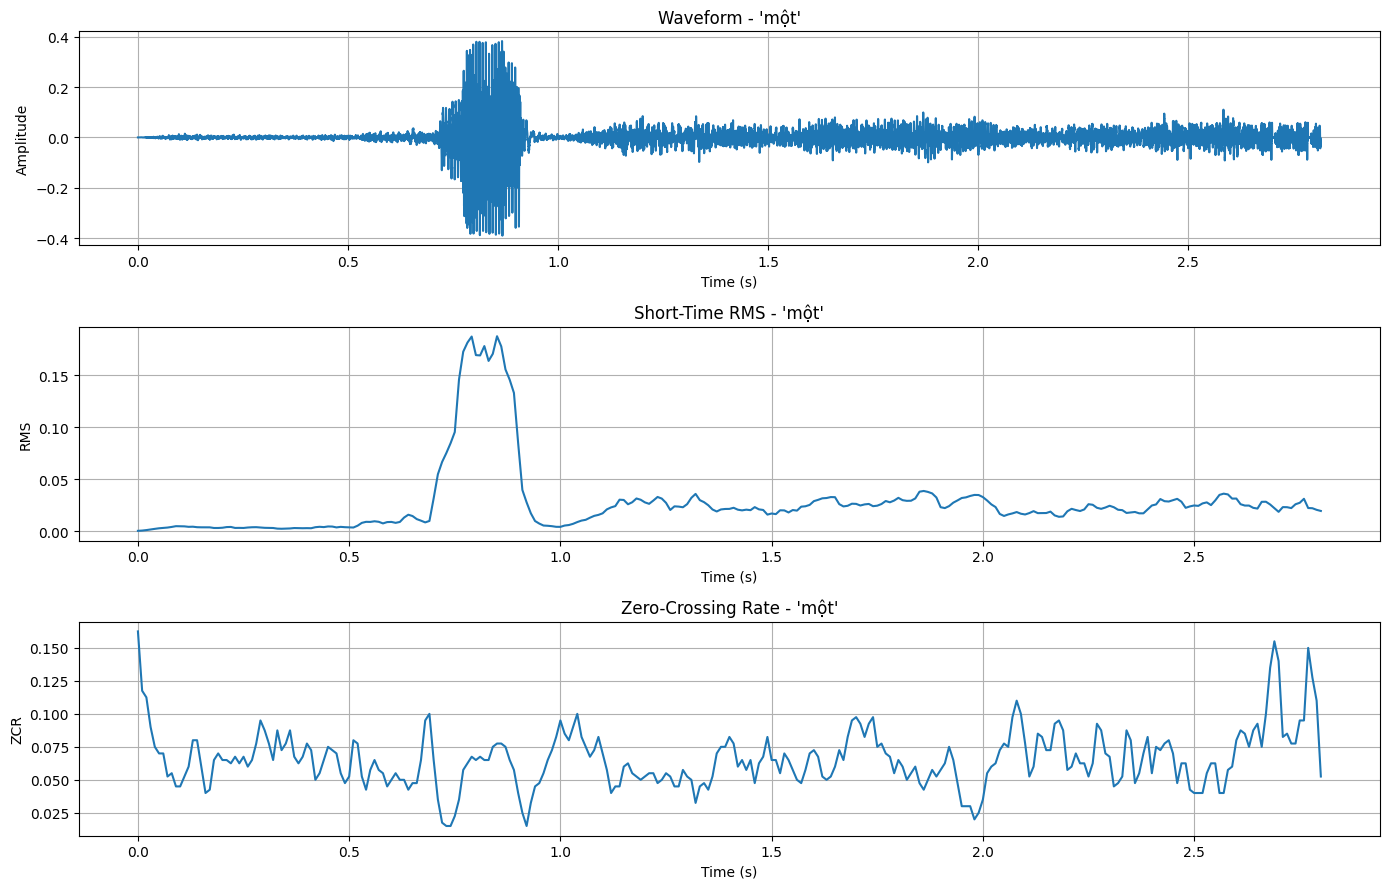

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\energy_zcr_một.png


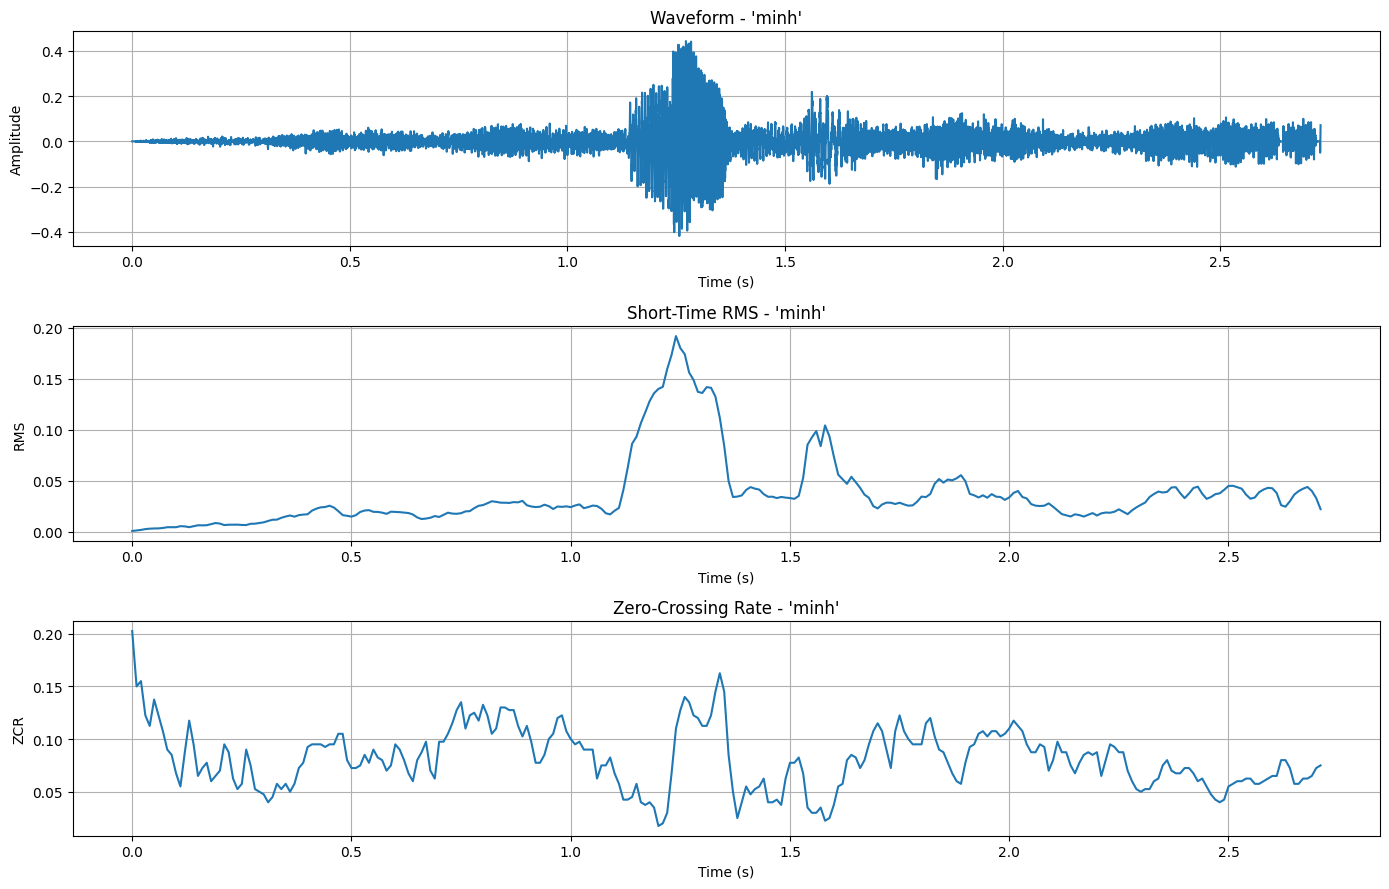

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\energy_zcr_minh.png


In [17]:
# ==========================================
# ENERGY + ZCR - 3 TỪ
# ==========================================

selected_files = [
    ("không", DATASET_DIR / "khong" / "khong_01.wav"),
    ("một", DATASET_DIR / "mot" / "mot_01.wav"),
    ("minh", DATASET_DIR / "minh" / "minh_01.wav")
]

for label, file_path in selected_files:

    result = analyze_energy_zcr(file_path)

    y = result["signal"]
    rms = result["rms"]
    zcr = result["zcr"]
    time = result["time"]

    fig, axes = plt.subplots(
        3, 1,
        figsize=(14, 9)
    )

    # Waveform
    signal_time = np.arange(len(y)) / SR

    axes[0].plot(signal_time, y)
    axes[0].set_title(f"Waveform - '{label}'")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)

    # RMS
    axes[1].plot(time, rms)
    axes[1].set_title(f"Short-Time RMS - '{label}'")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("RMS")
    axes[1].grid(True)

    # ZCR
    axes[2].plot(time, zcr)
    axes[2].set_title(f"Zero-Crossing Rate - '{label}'")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("ZCR")
    axes[2].grid(True)

    plt.tight_layout()

    output_file = (
        FIGURES_DIR /
        f"energy_zcr_{label}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ Đã lưu: {output_file}")

In [18]:
# ==========================================
# ENDPOINT DETECTION
# ==========================================

def endpoint_detection(
    signal,
    sr=SR,
    frame_length=FRAME_LENGTH,
    hop_length=HOP_LENGTH,
    margin_frames=2
):
    """
    Tìm start/end frame của vùng speech.

    Sử dụng:
    - log RMS energy
    - ZCR
    - adaptive threshold
    """

    frames = framing(
        signal,
        frame_length,
        hop_length
    )

    rms = calculate_rms(frames)
    zcr = calculate_zcr(frames)

    # Log-energy
    log_energy = np.log(
        rms + 1e-10
    )

    # Chuẩn hóa
    energy_min = np.min(log_energy)
    energy_max = np.max(log_energy)

    if energy_max - energy_min < 1e-8:
        energy_norm = np.zeros_like(log_energy)
    else:
        energy_norm = (
            (log_energy - energy_min)
            /
            (energy_max - energy_min)
        )

    # Ngưỡng năng lượng thích nghi
    low_energy = np.percentile(
        energy_norm,
        20
    )

    high_energy = np.percentile(
        energy_norm,
        80
    )

    energy_threshold = (
        low_energy
        + 0.20 * (high_energy - low_energy)
    )

    # Ngưỡng ZCR
    zcr_threshold = np.percentile(
        zcr,
        80
    )

    # Energy hoặc ZCR cao
    speech_mask = (
        (energy_norm >= energy_threshold)
        |
        (
            (zcr >= zcr_threshold)
            &
            (energy_norm >= low_energy)
        )
    )

    active_indices = np.where(
        speech_mask
    )[0]

    if len(active_indices) == 0:
        return {
            "start_frame": 0,
            "end_frame": len(frames) - 1,
            "start_sample": 0,
            "end_sample": len(signal),
            "frames": frames,
            "rms": rms,
            "zcr": zcr,
            "log_energy": log_energy,
            "speech_mask": speech_mask
        }

    start_frame = max(
        0,
        active_indices[0] - margin_frames
    )

    end_frame = min(
        len(frames) - 1,
        active_indices[-1] + margin_frames
    )

    start_sample = start_frame * hop_length

    end_sample = min(
        len(signal),
        end_frame * hop_length + frame_length
    )

    return {
        "start_frame": start_frame,
        "end_frame": end_frame,
        "start_sample": start_sample,
        "end_sample": end_sample,
        "frames": frames,
        "rms": rms,
        "zcr": zcr,
        "log_energy": log_energy,
        "speech_mask": speech_mask
    }


print("✓ Endpoint Detection đã sẵn sàng")

✓ Endpoint Detection đã sẵn sàng


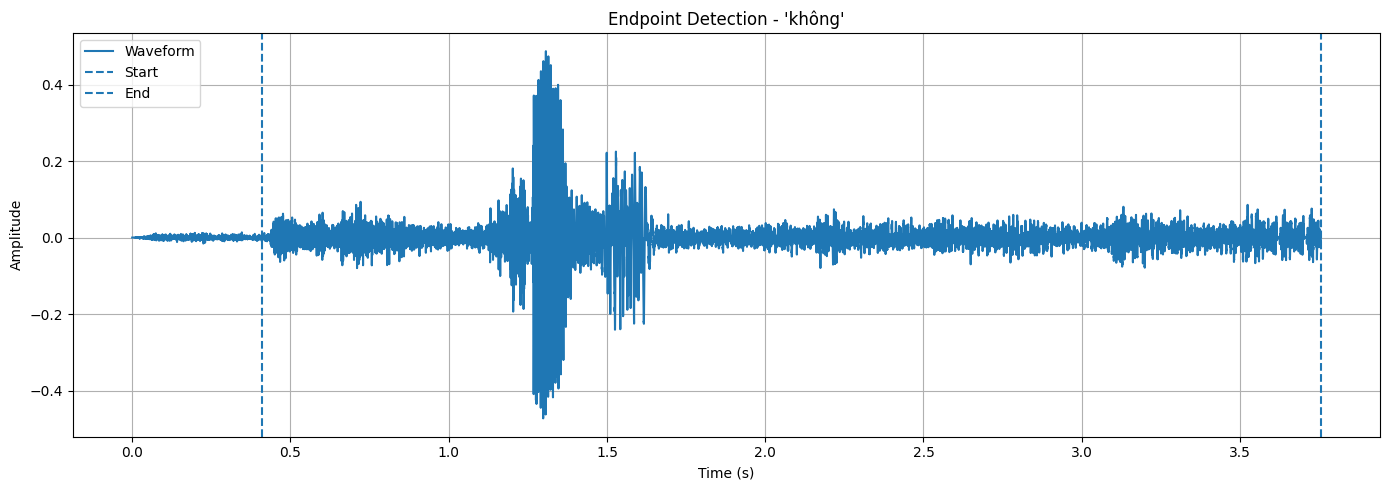

Start: 0.41 s
End: 3.7546875 s
Original duration: 3.7546875 s
Speech duration: 3.3446875 s


In [19]:
# ==========================================
# VẼ ENDPOINT DETECTION
# ==========================================

label = "không"
file_path = DATASET_DIR / "khong" / "khong_01.wav"

y, sr = librosa.load(
    file_path,
    sr=SR,
    mono=True
)

ep = endpoint_detection(y)

start_sample = ep["start_sample"]
end_sample = ep["end_sample"]

start_time = start_sample / SR
end_time = end_sample / SR

time = np.arange(len(y)) / SR

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    y,
    label="Waveform"
)

plt.axvline(
    start_time,
    linestyle="--",
    label="Start"
)

plt.axvline(
    end_time,
    linestyle="--",
    label="End"
)

plt.title(
    f"Endpoint Detection - '{label}'"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.tight_layout()

output_file = (
    FIGURES_DIR /
    "endpoint_detection.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Start:", start_time, "s")
print("End:", end_time, "s")
print("Original duration:", len(y) / SR, "s")
print("Speech duration:", end_time - start_time, "s")

In [20]:
# ==========================================
# TRIM SPEECH - TOÀN BỘ DATASET
# ==========================================

trim_records = []

for folder, (label, start, end) in word_groups.items():

    input_dir = DATASET_DIR / folder
    output_dir = TRIMMED_DIR / folder

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    files = sorted(
        input_dir.glob("*.wav")
    )

    for file_path in files:

        y, sr = librosa.load(
            file_path,
            sr=SR,
            mono=True
        )

        ep = endpoint_detection(y)

        start_sample = ep["start_sample"]
        end_sample = ep["end_sample"]

        trimmed = y[
            start_sample:end_sample
        ]

        output_file = (
            output_dir /
            file_path.name
        )

        sf.write(
            output_file,
            trimmed,
            SR
        )

        trim_records.append({
            "File": file_path.name,
            "Label": label,
            "Original Duration (s)": len(y) / SR,
            "Trimmed Duration (s)": len(trimmed) / SR,
            "Removed (s)": (
                len(y) - len(trimmed)
            ) / SR
        })

trim_df = pd.DataFrame(
    trim_records
)

display(trim_df)

trim_df.to_csv(
    FIGURES_DIR / "trim_statistics.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n✓ Đã trim toàn bộ 25 file")

,File,Label,Original Duration (s),Trimmed Duration (s),Removed (s)
0,khong_01.wav,không,3.754688,3.344688,0.41
1,khong_02.wav,không,2.986687,2.326687,0.66
2,khong_03.wav,không,3.840000,3.530000,0.31
3,khong_04.wav,không,2.901375,2.421375,0.48
4,khong_05.wav,không,3.072000,2.512000,0.56
5,mot_01.wav,một,2.816000,2.306000,0.51
6,mot_02.wav,một,2.560000,2.230000,0.33
7,mot_03.wav,một,2.560000,2.250000,0.31
8,mot_04.wav,một,3.072000,2.602000,0.47
9,mot_05.wav,một,2.560000,2.420000,0.14



✓ Đã trim toàn bộ 25 file


In [21]:
# ==========================================
# THỐNG KÊ ENDPOINT
# ==========================================

print("THỐNG KÊ TRIM")
print("=" * 60)

print(
    f"Thời lượng trung bình trước trim: "
    f"{trim_df['Original Duration (s)'].mean():.3f} s"
)

print(
    f"Thời lượng trung bình sau trim: "
    f"{trim_df['Trimmed Duration (s)'].mean():.3f} s"
)

print(
    f"Thời gian silence loại bỏ trung bình: "
    f"{trim_df['Removed (s)'].mean():.3f} s"
)

display(
    trim_df.groupby("Label")[
        [
            "Original Duration (s)",
            "Trimmed Duration (s)",
            "Removed (s)"
        ]
    ].mean()
)

THỐNG KÊ TRIM
Thời lượng trung bình trước trim: 2.625 s
Thời lượng trung bình sau trim: 2.292 s
Thời gian silence loại bỏ trung bình: 0.332 s


,Original Duration (s),Trimmed Duration (s),Removed (s)
Label,,,
không,3.310950,2.826950,0.484
minh,2.611225,2.355225,0.256
một,2.713600,2.361600,0.352
trắng,2.133350,1.833350,0.300
đỏ,2.355225,2.085225,0.270


In [22]:
# ==========================================
# PRE-EMPHASIS
# ==========================================

def pre_emphasis(
    signal,
    alpha=PRE_EMPHASIS
):
    """
    y[n] = x[n] - alpha*x[n-1]
    """

    emphasized = np.empty_like(
        signal,
        dtype=np.float32
    )

    emphasized[0] = signal[0]

    emphasized[1:] = (
        signal[1:]
        -
        alpha * signal[:-1]
    )

    return emphasized


print("✓ Pre-emphasis sẵn sàng")

✓ Pre-emphasis sẵn sàng


In [23]:
# ==========================================
# MFCC
# ==========================================

def extract_mfcc(
    file_path,
    include_delta=False
):
    """
    Trích xuất 13 MFCC.

    Pipeline:
    WAV
      ↓
    Pre-emphasis
      ↓
    Hamming
      ↓
    Mel filterbank
      ↓
    Log
      ↓
    DCT
      ↓
    13 MFCC
    """

    y, sr = librosa.load(
        file_path,
        sr=SR,
        mono=True
    )

    # Pre-emphasis
    y = pre_emphasis(y)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        win_length=FRAME_LENGTH,
        window="hamming"
    )

    # Chuyển thành [T, 13]
    features = mfcc.T

    if include_delta:

        delta = librosa.feature.delta(
            mfcc
        ).T

        features = np.concatenate(
            [features, delta],
            axis=1
        )

    return features


print("✓ Hàm MFCC đã sẵn sàng")

✓ Hàm MFCC đã sẵn sàng


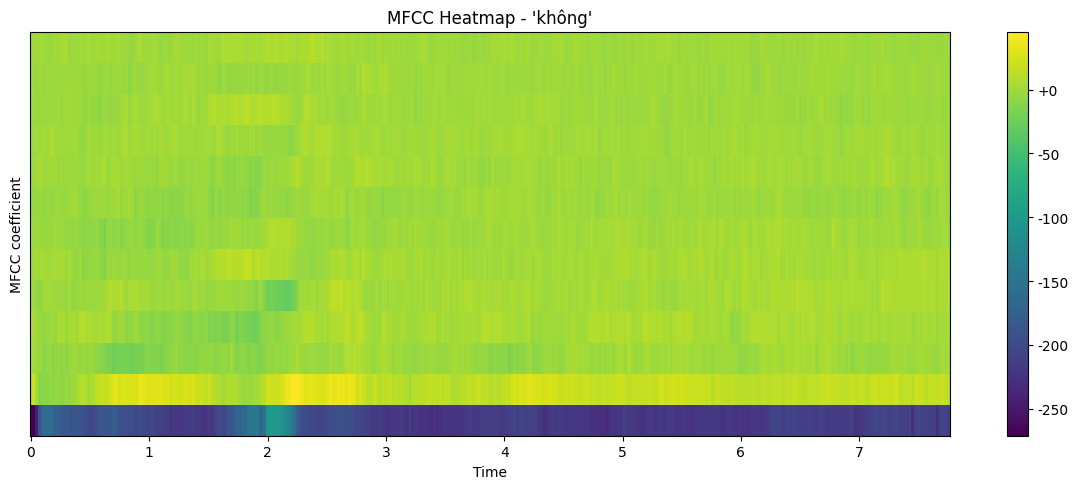

không: shape = (335, 13)


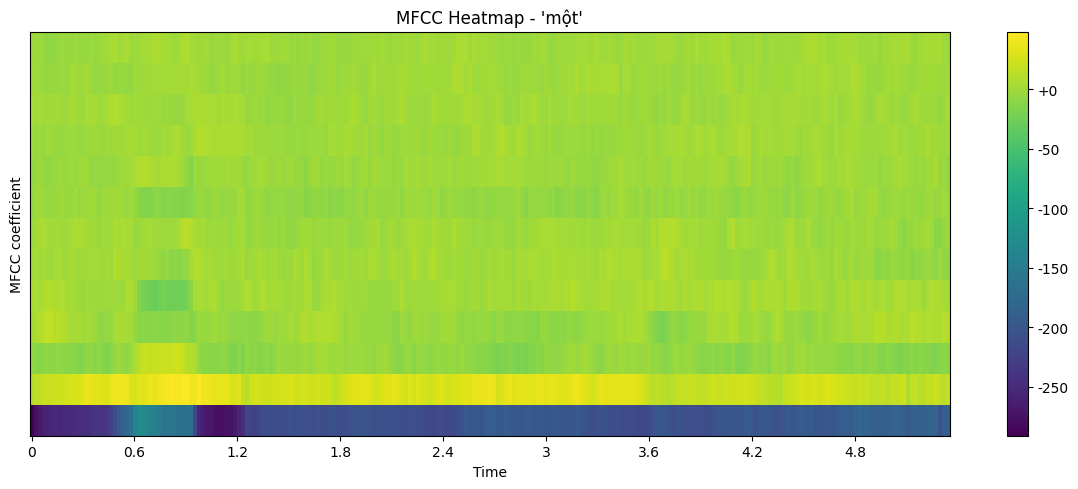

một: shape = (231, 13)


In [24]:
# ==========================================
# MFCC HEATMAP
# ==========================================

mfcc_examples = [
    ("không", TRIMMED_DIR / "khong" / "khong_01.wav"),
    ("một", TRIMMED_DIR / "mot" / "mot_01.wav")
]

for label, file_path in mfcc_examples:

    mfcc = extract_mfcc(
        file_path,
        include_delta=False
    )

    plt.figure(figsize=(12, 5))

    librosa.display.specshow(
        mfcc.T,
        x_axis="time",
        cmap="viridis"
    )

    plt.colorbar(
        format="%+2.0f"
    )

    plt.title(
        f"MFCC Heatmap - '{label}'"
    )

    plt.xlabel("Time")
    plt.ylabel("MFCC coefficient")

    plt.tight_layout()

    output_file = (
        FIGURES_DIR /
        f"mfcc_{label}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"{label}: shape = {mfcc.shape}"
    )

In [25]:
# ==========================================
# DTW - LOCAL DISTANCE
# ==========================================

def euclidean_distance(
    vector_a,
    vector_b
):
    return np.sqrt(
        np.sum(
            (vector_a - vector_b) ** 2
        )
    )


print(
    "Ví dụ:",
    euclidean_distance(
        np.array([1, 2]),
        np.array([2, 4])
    )
)

Ví dụ: 2.23606797749979


In [26]:
# ==========================================
# DTW TỰ CÀI ĐẶT
# ==========================================

def dtw_distance(
    X,
    Y,
    return_matrix=False,
    return_path=False
):
    """
    DTW tự cài đặt.

    X: [T1, D]
    Y: [T2, D]
    """

    T1 = X.shape[0]
    T2 = Y.shape[0]

    # Ma trận local distance
    local_dist = np.zeros(
        (T1, T2),
        dtype=np.float64
    )

    for i in range(T1):
        for j in range(T2):

            local_dist[i, j] = (
                euclidean_distance(
                    X[i],
                    Y[j]
                )
            )

    # Accumulated cost matrix
    cost = np.full(
        (T1 + 1, T2 + 1),
        np.inf,
        dtype=np.float64
    )

    cost[0, 0] = 0

    # Dynamic Programming
    for i in range(1, T1 + 1):

        for j in range(1, T2 + 1):

            cost[i, j] = (
                local_dist[i - 1, j - 1]
                +
                min(
                    cost[i - 1, j],
                    cost[i, j - 1],
                    cost[i - 1, j - 1]
                )
            )

    # --------------------------------------
    # Backtracking
    # --------------------------------------

    path = []

    i = T1
    j = T2

    while i > 0 and j > 0:

        path.append(
            (i - 1, j - 1)
        )

        candidates = [
            (
                cost[i - 1, j - 1],
                i - 1,
                j - 1
            ),
            (
                cost[i - 1, j],
                i - 1,
                j
            ),
            (
                cost[i, j - 1],
                i,
                j - 1
            )
        ]

        _, i, j = min(
            candidates,
            key=lambda x: x[0]
        )

    path.reverse()

    total_cost = cost[T1, T2]

    path_length = len(path)

    normalized_cost = (
        total_cost / path_length
        if path_length > 0
        else np.inf
    )

    result = {
        "distance": total_cost,
        "normalized_distance": normalized_cost,
        "path": path,
        "local_distance": local_dist,
        "cost_matrix": cost[1:, 1:]
    }

    return result


print("✓ DTW tự cài đặt hoàn tất")

✓ DTW tự cài đặt hoàn tất


In [27]:
# ==========================================
# DTW - CÙNG TỪ
# ==========================================

file_a = (
    TRIMMED_DIR /
    "khong" /
    "khong_01.wav"
)

file_b = (
    TRIMMED_DIR /
    "khong" /
    "khong_02.wav"
)

mfcc_a = extract_mfcc(file_a)
mfcc_b = extract_mfcc(file_b)

dtw_same = dtw_distance(
    mfcc_a,
    mfcc_b
)

print("DTW cùng từ: KHÔNG")
print("=" * 50)

print(
    "Total DTW cost:",
    dtw_same["distance"]
)

print(
    "Normalized DTW:",
    dtw_same["normalized_distance"]
)

print(
    "Path length:",
    len(dtw_same["path"])
)

DTW cùng từ: KHÔNG
Total DTW cost: 10010.956785678864
Normalized DTW: 29.35764453278259
Path length: 341


In [28]:
# ==========================================
# DTW - HAI TỪ KHÁC NHAU
# ==========================================

file_c = (
    TRIMMED_DIR /
    "mot" /
    "mot_01.wav"
)

mfcc_c = extract_mfcc(file_c)

dtw_different = dtw_distance(
    mfcc_a,
    mfcc_c
)

print("DTW khác từ: KHÔNG ↔ MỘT")
print("=" * 50)

print(
    "Total DTW cost:",
    dtw_different["distance"]
)

print(
    "Normalized DTW:",
    dtw_different["normalized_distance"]
)

print(
    "Path length:",
    len(dtw_different["path"])
)

print("\nSO SÁNH")
print(
    "Cùng từ:",
    dtw_same["normalized_distance"]
)

print(
    "Khác từ:",
    dtw_different["normalized_distance"]
)

DTW khác từ: KHÔNG ↔ MỘT
Total DTW cost: 10926.954422950745
Normalized DTW: 32.04385461275878
Path length: 341

SO SÁNH
Cùng từ: 29.35764453278259
Khác từ: 32.04385461275878


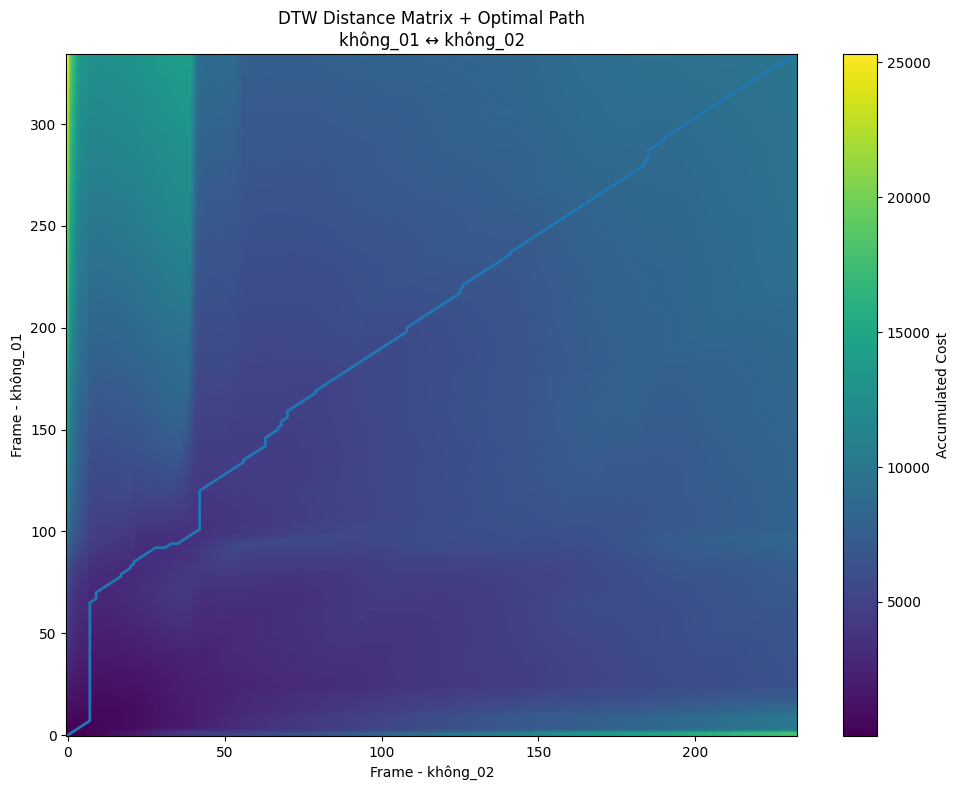

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\dtw_optimal_path.png


In [29]:
# ==========================================
# VẼ DTW MATRIX + OPTIMAL PATH
# ==========================================

matrix = dtw_same["cost_matrix"]
path = dtw_same["path"]

plt.figure(figsize=(10, 8))

plt.imshow(
    matrix,
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

path_i = [p[0] for p in path]
path_j = [p[1] for p in path]

plt.plot(
    path_j,
    path_i,
    linewidth=2
)

plt.colorbar(
    label="Accumulated Cost"
)

plt.title(
    "DTW Distance Matrix + Optimal Path\n"
    "không_01 ↔ không_02"
)

plt.xlabel("Frame - không_02")
plt.ylabel("Frame - không_01")

plt.tight_layout()

output_file = (
    FIGURES_DIR /
    "dtw_optimal_path.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Đã lưu:", output_file)

In [30]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

train_files = []
test_files = []

for folder, (label, start, end) in word_groups.items():

    files = sorted(
        (TRIMMED_DIR / folder).glob("*.wav")
    )

    # 3 file đầu làm template
    for file in files[:3]:

        train_files.append({
            "label": label,
            "file": file,
            "folder": folder
        })

    # 2 file cuối làm test
    for file in files[3:]:

        test_files.append({
            "label": label,
            "file": file,
            "folder": folder
        })


print("TRAIN / TEMPLATE:", len(train_files))
print("TEST:", len(test_files))

print("\nTRAIN:")
for item in train_files:
    print(
        item["label"],
        "->",
        item["file"].name
    )

print("\nTEST:")
for item in test_files:
    print(
        item["label"],
        "->",
        item["file"].name
    )

TRAIN / TEMPLATE: 15
TEST: 10

TRAIN:
không -> khong_01.wav
không -> khong_02.wav
không -> khong_03.wav
một -> mot_01.wav
một -> mot_02.wav
một -> mot_03.wav
minh -> minh_01.wav
minh -> minh_02.wav
minh -> minh_03.wav
đỏ -> do_01.wav
đỏ -> do_02.wav
đỏ -> do_03.wav
trắng -> trang_01.wav
trắng -> trang_02.wav
trắng -> trang_03.wav

TEST:
không -> khong_04.wav
không -> khong_05.wav
một -> mot_04.wav
một -> mot_05.wav
minh -> minh_04.wav
minh -> minh_05.wav
đỏ -> do_04.wav
đỏ -> do_05.wav
trắng -> trang_04.wav
trắng -> trang_05.wav


In [31]:
# ==========================================
# PRECOMPUTE MFCC
# ==========================================

feature_cache = {}

all_files = (
    train_files
    + test_files
)

for item in all_files:

    key = str(
        item["file"].resolve()
    )

    feature_cache[key] = (
        extract_mfcc(
            item["file"],
            include_delta=False
        )
    )

print(
    "✓ Đã trích MFCC cho",
    len(feature_cache),
    "file"
)

✓ Đã trích MFCC cho 25 file


In [32]:
# ==========================================
# NEAREST TEMPLATE RECOGNIZER
# ==========================================

def recognize_nearest_template(
    test_item,
    templates,
    feature_cache
):

    test_key = str(
        test_item["file"].resolve()
    )

    test_feature = feature_cache[test_key]

    scores = []

    for template in templates:

        template_key = str(
            template["file"].resolve()
        )

        template_feature = (
            feature_cache[template_key]
        )

        result = dtw_distance(
            test_feature,
            template_feature
        )

        scores.append({
            "template_label": template["label"],
            "template_file": template["file"].name,
            "distance": result["normalized_distance"],
            "path_length": len(result["path"])
        })

    # Sắp xếp theo khoảng cách
    scores = sorted(
        scores,
        key=lambda x: x["distance"]
    )

    # Top-1 template
    best = scores[0]

    # Top-3 nhãn
    label_best = {}

    for item in scores:

        label = item["template_label"]

        if (
            label not in label_best
            or
            item["distance"]
            < label_best[label]
        ):
            label_best[label] = (
                item["distance"]
            )

    top_labels = sorted(
        label_best.items(),
        key=lambda x: x[1]
    )[:3]

    return {
        "prediction": best["template_label"],
        "scores": scores,
        "top_labels": top_labels
    }


print("✓ Bộ nhận dạng đã sẵn sàng")

✓ Bộ nhận dạng đã sẵn sàng


In [33]:
# ==========================================
# CHẠY NHẬN DẠNG
# ==========================================

recognition_results = []

for test_item in test_files:

    result = recognize_nearest_template(
        test_item,
        train_files,
        feature_cache
    )

    prediction = result["prediction"]

    top_labels = result["top_labels"]

    top1_label = (
        top_labels[0][0]
        if len(top_labels) > 0
        else ""
    )

    top1_score = (
        top_labels[0][1]
        if len(top_labels) > 0
        else np.nan
    )

    top2_label = (
        top_labels[1][0]
        if len(top_labels) > 1
        else ""
    )

    top2_score = (
        top_labels[1][1]
        if len(top_labels) > 1
        else np.nan
    )

    top3_label = (
        top_labels[2][0]
        if len(top_labels) > 2
        else ""
    )

    top3_score = (
        top_labels[2][1]
        if len(top_labels) > 2
        else np.nan
    )

    recognition_results.append({
        "File": test_item["file"].name,
        "True Label": test_item["label"],
        "Predicted Label": prediction,
        "Top1 Label": top1_label,
        "Top1 DTW": top1_score,
        "Top2 Label": top2_label,
        "Top2 DTW": top2_score,
        "Top3 Label": top3_label,
        "Top3 DTW": top3_score
    })

recognition_df = pd.DataFrame(
    recognition_results
)

display(recognition_df)

,File,True Label,Predicted Label,Top1 Label,Top1 DTW,Top2 Label,Top2 DTW,Top3 Label,Top3 DTW
0,khong_04.wav,không,không,không,23.035705,trắng,28.152412,một,29.086942
1,khong_05.wav,không,không,không,24.163135,một,28.382714,đỏ,30.158852
2,mot_04.wav,một,một,một,23.128260,không,24.585854,đỏ,28.514550
3,mot_05.wav,một,không,không,25.130506,một,25.367426,đỏ,27.693912
4,minh_04.wav,minh,minh,minh,25.599792,không,27.921686,đỏ,32.083722
5,minh_05.wav,minh,minh,minh,22.678331,không,29.483143,một,29.737081
6,do_04.wav,đỏ,không,không,24.559950,đỏ,26.565253,một,27.102051
7,do_05.wav,đỏ,không,không,25.669635,đỏ,27.183226,một,28.920940
8,trang_04.wav,trắng,trắng,trắng,23.856807,không,29.355625,minh,29.554176
9,trang_05.wav,trắng,trắng,trắng,27.372901,không,28.780501,minh,33.273677


In [34]:
# ==========================================
# TOP-3 CHO 5 TEST FILE
# ==========================================

for test_item in test_files[:5]:

    result = recognize_nearest_template(
        test_item,
        train_files,
        feature_cache
    )

    print("=" * 60)

    print(
        "Test:",
        test_item["file"].name
    )

    print(
        "Nhãn thật:",
        test_item["label"]
    )

    print(
        "Dự đoán:",
        result["prediction"]
    )

    print("\nTop-3:")

    for rank, (label, score) in enumerate(
        result["top_labels"],
        start=1
    ):

        print(
            f"{rank}. {label:<8} "
            f"DTW = {score:.4f}"
        )

Test: khong_04.wav
Nhãn thật: không
Dự đoán: không

Top-3:
1. không    DTW = 23.0357
2. trắng    DTW = 28.1524
3. một      DTW = 29.0869
Test: khong_05.wav
Nhãn thật: không
Dự đoán: không

Top-3:
1. không    DTW = 24.1631
2. một      DTW = 28.3827
3. đỏ       DTW = 30.1589
Test: mot_04.wav
Nhãn thật: một
Dự đoán: một

Top-3:
1. một      DTW = 23.1283
2. không    DTW = 24.5859
3. đỏ       DTW = 28.5145
Test: mot_05.wav
Nhãn thật: một
Dự đoán: không

Top-3:
1. không    DTW = 25.1305
2. một      DTW = 25.3674
3. đỏ       DTW = 27.6939
Test: minh_04.wav
Nhãn thật: minh
Dự đoán: minh

Top-3:
1. minh     DTW = 25.5998
2. không    DTW = 27.9217
3. đỏ       DTW = 32.0837


In [35]:
# ==========================================
# ACCURACY
# ==========================================

y_true = recognition_df[
    "True Label"
].tolist()

y_pred = recognition_df[
    "Predicted Label"
].tolist()

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("=" * 50)
print("KẾT QUẢ NHẬN DẠNG")
print("=" * 50)

print(
    f"Đúng: "
    f"{sum(a == b for a, b in zip(y_true, y_pred))}"
    f"/{len(y_true)}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

KẾT QUẢ NHẬN DẠNG
Đúng: 7/10
Accuracy: 70.00%


Confusion Matrix:
[[2 0 0 0 0]
 [1 1 0 0 0]
 [0 0 2 0 0]
 [2 0 0 0 0]
 [0 0 0 0 2]]


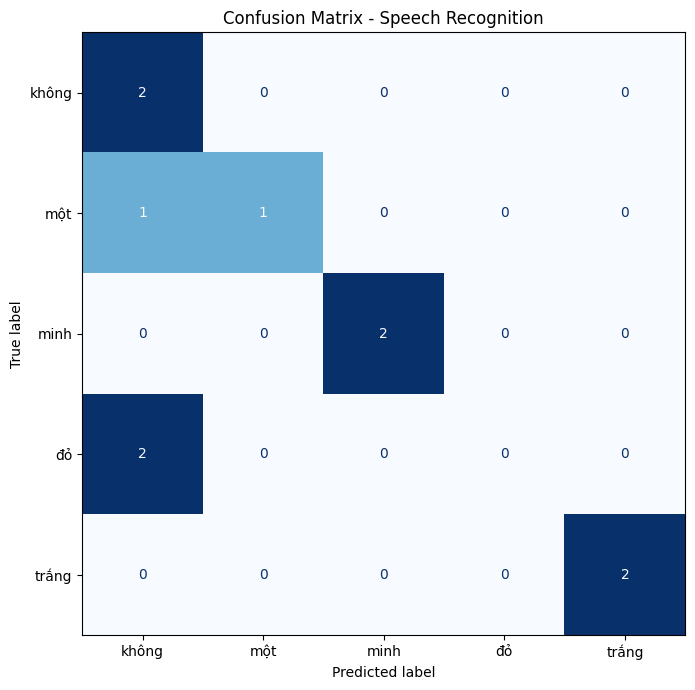

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\confusion_matrix.png


In [36]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

labels = [
    "không",
    "một",
    "minh",
    "đỏ",
    "trắng"
]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

print("Confusion Matrix:")
print(cm)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Confusion Matrix - Speech Recognition"
)

plt.tight_layout()

output_file = (
    FIGURES_DIR /
    "confusion_matrix.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Đã lưu:", output_file)

In [37]:
# ==========================================
# LƯU RESULTS.CSV
# ==========================================

results_file = (
    PROJECT_DIR /
    "results.csv"
)

recognition_df.to_csv(
    results_file,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✓ Đã lưu kết quả:",
    results_file
)

display(recognition_df)

✓ Đã lưu kết quả: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\results.csv


,File,True Label,Predicted Label,Top1 Label,Top1 DTW,Top2 Label,Top2 DTW,Top3 Label,Top3 DTW
0,khong_04.wav,không,không,không,23.035705,trắng,28.152412,một,29.086942
1,khong_05.wav,không,không,không,24.163135,một,28.382714,đỏ,30.158852
2,mot_04.wav,một,một,một,23.128260,không,24.585854,đỏ,28.514550
3,mot_05.wav,một,không,không,25.130506,một,25.367426,đỏ,27.693912
4,minh_04.wav,minh,minh,minh,25.599792,không,27.921686,đỏ,32.083722
5,minh_05.wav,minh,minh,minh,22.678331,không,29.483143,một,29.737081
6,do_04.wav,đỏ,không,không,24.559950,đỏ,26.565253,một,27.102051
7,do_05.wav,đỏ,không,không,25.669635,đỏ,27.183226,một,28.920940
8,trang_04.wav,trắng,trắng,trắng,23.856807,không,29.355625,minh,29.554176
9,trang_05.wav,trắng,trắng,trắng,27.372901,không,28.780501,minh,33.273677


In [38]:
# ==========================================
# E1 - MFCC KHÔNG ENDPOINT
# ==========================================

raw_feature_cache = {}

for item in train_files + test_files:

    key = str(
        item["file"].resolve()
    )

    raw_feature_cache[key] = (
        extract_mfcc(
            item["file"],
            include_delta=False
        )
    )

print(
    "✓ Đã trích MFCC cho dữ liệu KHÔNG TRIM"
)

✓ Đã trích MFCC cho dữ liệu KHÔNG TRIM


In [39]:
# ==========================================
# E1-A: KHÔNG ENDPOINT
# ==========================================

raw_results = []

for test_item in test_files:

    test_key = str(
        test_item["file"].resolve()
    )

    test_feature = (
        raw_feature_cache[test_key]
    )

    scores = []

    for template in train_files:

        template_key = str(
            template["file"].resolve()
        )

        result = dtw_distance(
            test_feature,
            raw_feature_cache[template_key]
        )

        scores.append({
            "label": template["label"],
            "distance": result[
                "normalized_distance"
            ],
            "path_length": len(
                result["path"]
            )
        })

    best = min(
        scores,
        key=lambda x: x["distance"]
    )

    raw_results.append({
        "File": test_item["file"].name,
        "True": test_item["label"],
        "Predicted": best["label"],
        "DTW": best["distance"],
        "Path Length": best["path_length"]
    })


raw_df = pd.DataFrame(
    raw_results
)

raw_accuracy = accuracy_score(
    raw_df["True"],
    raw_df["Predicted"]
)

print(
    f"E1-A - Accuracy không Endpoint: "
    f"{raw_accuracy * 100:.2f}%"
)

E1-A - Accuracy không Endpoint: 70.00%


In [40]:
# ==========================================
# E1-B: CÓ ENDPOINT
# ==========================================

trim_accuracy = accuracy

print(
    f"E1-B - Accuracy có Endpoint: "
    f"{trim_accuracy * 100:.2f}%"
)

print("\nSO SÁNH E1")
print("=" * 50)

print(
    f"Không Endpoint: "
    f"{raw_accuracy * 100:.2f}%"
)

print(
    f"Có Endpoint:    "
    f"{trim_accuracy * 100:.2f}%"
)

print(
    f"Thay đổi:       "
    f"{(trim_accuracy - raw_accuracy) * 100:+.2f}%"
)

E1-B - Accuracy có Endpoint: 70.00%

SO SÁNH E1
Không Endpoint: 70.00%
Có Endpoint:    70.00%
Thay đổi:       +0.00%


In [41]:
# ==========================================
# E1 - SO SÁNH DTW PATH
# ==========================================

raw_mean_path = (
    raw_df["Path Length"].mean()
)

trim_path_lengths = []

for test_item in test_files:

    test_key = str(
        test_item["file"].resolve()
    )

    test_feature = (
        feature_cache[test_key]
    )

    for template in train_files:

        template_key = str(
            template["file"].resolve()
        )

        result = dtw_distance(
            test_feature,
            feature_cache[template_key]
        )

        if (
            template["label"]
            == test_item["label"]
        ):
            trim_path_lengths.append(
                len(result["path"])
            )

            break


trim_mean_path = np.mean(
    trim_path_lengths
)

print(
    "Mean DTW path length - Không trim:",
    raw_mean_path
)

print(
    "Mean DTW path length - Có trim:",
    trim_mean_path
)

Mean DTW path length - Không trim: 336.8
Mean DTW path length - Có trim: 286.1


In [42]:
# ==========================================
# E2 - MFCC + DELTA
# ==========================================

delta_feature_cache = {}

for item in train_files + test_files:

    key = str(
        item["file"].resolve()
    )

    delta_feature_cache[key] = (
        extract_mfcc(
            item["file"],
            include_delta=True
        )
    )

print(
    "✓ MFCC + Delta đã được tính"
)

# Kiểm tra chiều
example_key = str(
    train_files[0]["file"].resolve()
)

print(
    "MFCC shape:",
    feature_cache[example_key].shape
)

print(
    "MFCC + Delta shape:",
    delta_feature_cache[example_key].shape
)

✓ MFCC + Delta đã được tính
MFCC shape: (335, 13)
MFCC + Delta shape: (335, 26)


In [43]:
# ==========================================
# E2 - MFCC + DELTA RECOGNITION
# ==========================================

delta_results = []

for test_item in test_files:

    test_key = str(
        test_item["file"].resolve()
    )

    test_feature = (
        delta_feature_cache[test_key]
    )

    scores = []

    for template in train_files:

        template_key = str(
            template["file"].resolve()
        )

        template_feature = (
            delta_feature_cache[template_key]
        )

        result = dtw_distance(
            test_feature,
            template_feature
        )

        scores.append({
            "label": template["label"],
            "distance": result[
                "normalized_distance"
            ],
            "path_length": len(
                result["path"]
            )
        })

    best = min(
        scores,
        key=lambda x: x["distance"]
    )

    delta_results.append({
        "File": test_item["file"].name,
        "True": test_item["label"],
        "Predicted": best["label"],
        "DTW": best["distance"],
        "Path Length": best["path_length"]
    })


delta_df = pd.DataFrame(
    delta_results
)

delta_accuracy = accuracy_score(
    delta_df["True"],
    delta_df["Predicted"]
)

print(
    f"E2 - MFCC + Delta Accuracy: "
    f"{delta_accuracy * 100:.2f}%"
)

E2 - MFCC + Delta Accuracy: 80.00%


In [44]:
# ==========================================
# E2 - SO SÁNH MFCC VS MFCC + DELTA
# ==========================================

mfcc_accuracy = accuracy

print("=" * 60)
print("E2 - SO SÁNH ĐẶC TRƯNG")
print("=" * 60)

print(
    f"13 MFCC:          "
    f"{mfcc_accuracy * 100:.2f}%"
)

print(
    f"13 MFCC + Delta:  "
    f"{delta_accuracy * 100:.2f}%"
)

print(
    f"Thay đổi: "
    f"{(delta_accuracy - mfcc_accuracy) * 100:+.2f}%"
)

E2 - SO SÁNH ĐẶC TRƯNG
13 MFCC:          70.00%
13 MFCC + Delta:  80.00%
Thay đổi: +10.00%


In [45]:
# ==========================================
# TỔNG HỢP E1 + E2
# ==========================================

comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline - MFCC 13 + Endpoint",
        "E1 - No Endpoint",
        "E1 - With Endpoint",
        "E2 - MFCC 13",
        "E2 - MFCC 13 + Delta"
    ],

    "Accuracy (%)": [
        accuracy * 100,
        raw_accuracy * 100,
        trim_accuracy * 100,
        mfcc_accuracy * 100,
        delta_accuracy * 100
    ]
})

display(
    comparison_df
)

comparison_df.to_csv(
    PROJECT_DIR / "experiment_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

,Experiment,Accuracy (%)
0,Baseline - MFCC 13 + Endpoint,70.0
1,E1 - No Endpoint,70.0
2,E1 - With Endpoint,70.0
3,E2 - MFCC 13,70.0
4,E2 - MFCC 13 + Delta,80.0


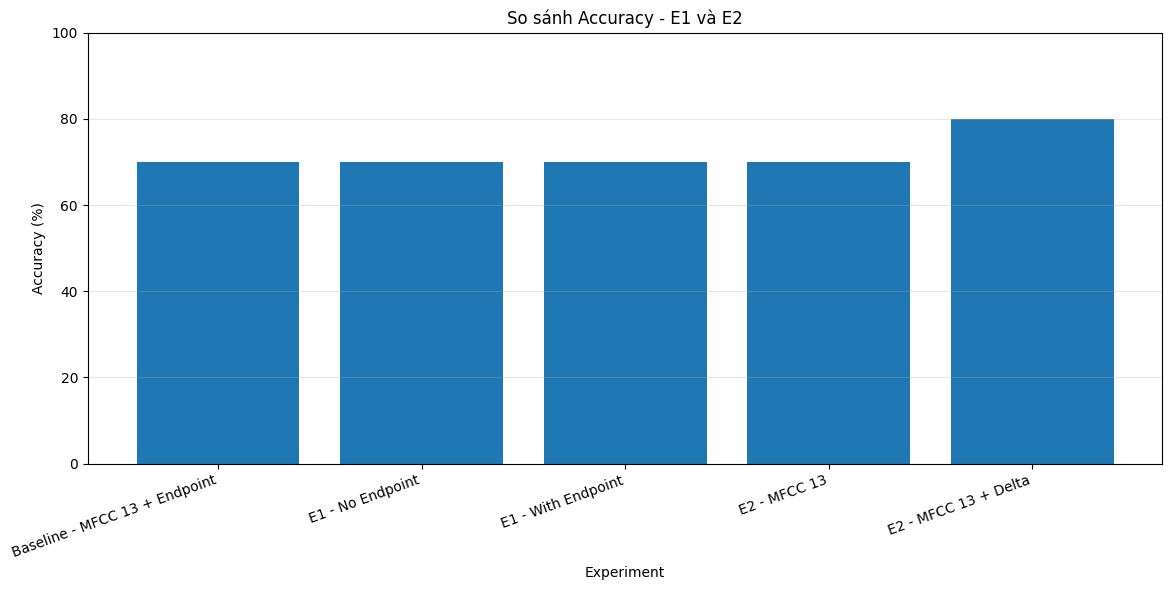

✓ Đã lưu: c:\XLAT&TN\Lab2_2351260670_NguyenAnhMinh\figures\experiment_comparison.png


In [46]:
# ==========================================
# BIỂU ĐỒ SO SÁNH E1 + E2
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Experiment"],
    comparison_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Experiment")
plt.title(
    "So sánh Accuracy - E1 và E2"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

output_file = (
    FIGURES_DIR /
    "experiment_comparison.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Đã lưu:",
    output_file
)

In [47]:
# ==========================================
# FINAL CHECK - LAB 2
# ==========================================

print("=" * 70)
print("FINAL CHECK - LAB 2")
print("=" * 70)

# Dataset
wav_count = len(
    list(DATASET_DIR.rglob("*.wav"))
)

trim_count = len(
    list(TRIMMED_DIR.rglob("*.wav"))
)

print(
    f"\n1. WAV gốc:       {wav_count} file"
)

print(
    f"2. WAV đã trim:   {trim_count} file"
)

print(
    f"3. Train:         {len(train_files)} file"
)

print(
    f"4. Test:          {len(test_files)} file"
)

print(
    f"5. Accuracy:      {accuracy * 100:.2f}%"
)

print(
    f"6. E1 No Endpoint:"
    f" {raw_accuracy * 100:.2f}%"
)

print(
    f"7. E1 Endpoint:   "
    f"{trim_accuracy * 100:.2f}%"
)

print(
    f"8. E2 MFCC:       "
    f"{mfcc_accuracy * 100:.2f}%"
)

print(
    f"9. E2 MFCC+Delta: "
    f"{delta_accuracy * 100:.2f}%"
)

print("\nCác file hình:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print("   ✓", file.name)

print("\nCác file kết quả:")
for file in [
    PROJECT_DIR / "results.csv",
    PROJECT_DIR / "experiment_comparison.csv"
]:
    if file.exists():
        print("   ✓", file.name)

print("\n" + "=" * 70)
print("HOÀN TẤT PIPELINE LAB 2")
print("=" * 70)

FINAL CHECK - LAB 2

1. WAV gốc:       25 file
2. WAV đã trim:   25 file
3. Train:         15 file
4. Test:          10 file
5. Accuracy:      70.00%
6. E1 No Endpoint: 70.00%
7. E1 Endpoint:   70.00%
8. E2 MFCC:       70.00%
9. E2 MFCC+Delta: 80.00%

Các file hình:
   ✓ confusion_matrix.png
   ✓ dtw_optimal_path.png
   ✓ endpoint_detection.png
   ✓ energy_zcr_không.png
   ✓ energy_zcr_minh.png
   ✓ energy_zcr_một.png
   ✓ experiment_comparison.png
   ✓ mfcc_không.png
   ✓ mfcc_một.png

Các file kết quả:
   ✓ results.csv
   ✓ experiment_comparison.csv

HOÀN TẤT PIPELINE LAB 2
